![](ai_statement.png)

# 4.10

(a)

From eq 4.5.3

$$ \Delta f = 2f_0 \sqrt{\frac{2K_B T ln(2)}{M c^2}}$$


Where M is the mass of the lasing atom or molecule

For fun I calculate the full width half max linewidths for the laser. Later I calculate the rms linewidths

### FWHM Linewidth Calculation

In [1]:
from scipy.constants import c, k
import numpy as np

T = 130 + 273.15 # Degrees kelvin
lam0 = 632.8e-9
nu0 = c / 632.8e-9
L=40e-2
M = 3.35e-26

f0 = c/lam0
delta_nu_fwhm = 2*f0*np.sqrt((2*k*T*np.log(2))/(M*c**2))
delta_lam_fwhm = delta_nu_fwhm*np.abs(-lam0/f0)

print(f"∆nu_fwhm = {delta_nu_fwhm:e} Hz")
print(f"∆lam_fwhm = {delta_lam_fwhm:e} m")

∆nu_fwhm = 1.516854e+09 Hz
∆lam_fwhm = 2.026078e-12 m


### RMS Linewidth calculation

In [2]:
v_x = np.sqrt(k*T/M)
nu1 = nu0*(1 - v_x / c)
nu2 = nu0*(1 + v_x / c)

delta_nu_rms = nu2 - nu1
delta_lam_rms = delta_nu_rms*np.abs(-lam0/f0)
print(f"∆ nu_rms = {delta_nu_rms:e} Hz")
print(f"∆ lambda_rms = {delta_lam_rms:e} m")

∆ nu_rms = 1.288297e+09 Hz
∆ lambda_rms = 1.720792e-12 m


(b through c)

Each mode in the cavity satisfies $m(\lambda/2) = L$

In [3]:
m0 = round(2*L/lam0)

print(f"Central mode number rounded to the nearest integer: {m0}")

Central mode number rounded to the nearest integer: 1264223


NOTE: I DO PART C BEFORE FINISHING PART B

recall, the separation between two resonant modes is 
$$ \Delta \lambda_m \approx \frac{\lambda_0^2}{2L}$$

and 

$$ \Delta \nu_m = \frac{c}{2L} $$

In [4]:
delta_lam_m = lam0**2 / (2*L)
delta_nu_m = c / (2*L)

num_modes = delta_lam_fwhm / delta_lam_m

print(f"Given the separation of modes in wavelength is {delta_lam_m:e} m")
print(f"And separation in frequency is {delta_nu_m:e} Hz")
print(f"We expect that the number of modes that satisfy our conditions is approximately {num_modes}")

Given the separation of modes in wavelength is 5.005448e-13 m
And separation in frequency is 3.747406e+08 Hz
We expect that the number of modes that satisfy our conditions is approximately 4.0477446503852015


Thus, we expect between 4 and 5 modes in the cavity

Let us solve for the exact mode numbers. We have already found that the mode number of the central mode is 1264223 (which we rounded up to the nearest integer)

If instead, we only allow valid modes between lam_min = lam0 - 0.5delta_lam and lam_max = lam0 + 0.5delta_lam, then we can check in this range for integer solutions m

In [5]:
import math

@np.vectorize
def round_up(x):
    return math.ceil(x)

def find_mode_numbers(lam0, delta_lam, L):
    lam_min = lam0 - delta_lam/2
    lam_max = lam0 + delta_lam/2

    
    lam = np.linspace(lam_min, lam_max, 1000)
    
    mode_numbers = list(set(round_up(2*L/lam)))
    mode_numbers.sort()
    
    mode_numbers = [int(m) for m in mode_numbers ]


    mode_numbers_to_remove = []
    # Make sure that min and max in range
    for m in [max(mode_numbers), min(mode_numbers)]:
        lam = 2*L/m
        if not (lam_min < lam) or not (lam < lam_max):
            mode_numbers_to_remove.append(m)
    for m in mode_numbers_to_remove:
        mode_numbers.remove(m)

    return mode_numbers

mode_numbers = find_mode_numbers(lam0, delta_lam_fwhm, L)

print(f"The mode numbers that satisfy our conditions are: {mode_numbers}")

The mode numbers that satisfy our conditions are: [1264221, 1264222, 1264223, 1264224]


(d)

Beginning with the cavity condition:  
$$ m(\lambda_m/2) = L $$
where m is an integer. Solving for  $\lambda$  
$$ \lambda_m = 2L/m $$

If the length changes by $\delta L$, we will have a new resonant wavelength with   
$$ \lambda_m' = 2(L + \delta L)/m $$
$$ \lambda_m' = 2L/m + 2\delta L/m $$
$$ \lambda_m' = \lambda_m + 2\delta L/m $$
$$ \lambda_m' = \lambda_m + \delta \lambda_m $$

Where, 
$$\delta \lambda_m = 2\delta L/m = (2/m)\delta L$$

Now, we can solve for $2/m$  
$$ \lambda_m = 2L/m $$
$$ 2/m = \lambda_m / L $$

Substituting we have:  
$$ \delta \lambda_m =(\lambda_m / L)\delta L $$

1293467260.5914347
1516854147.6191628
1.7276973959345904e-12
2.0260775364781306e-12


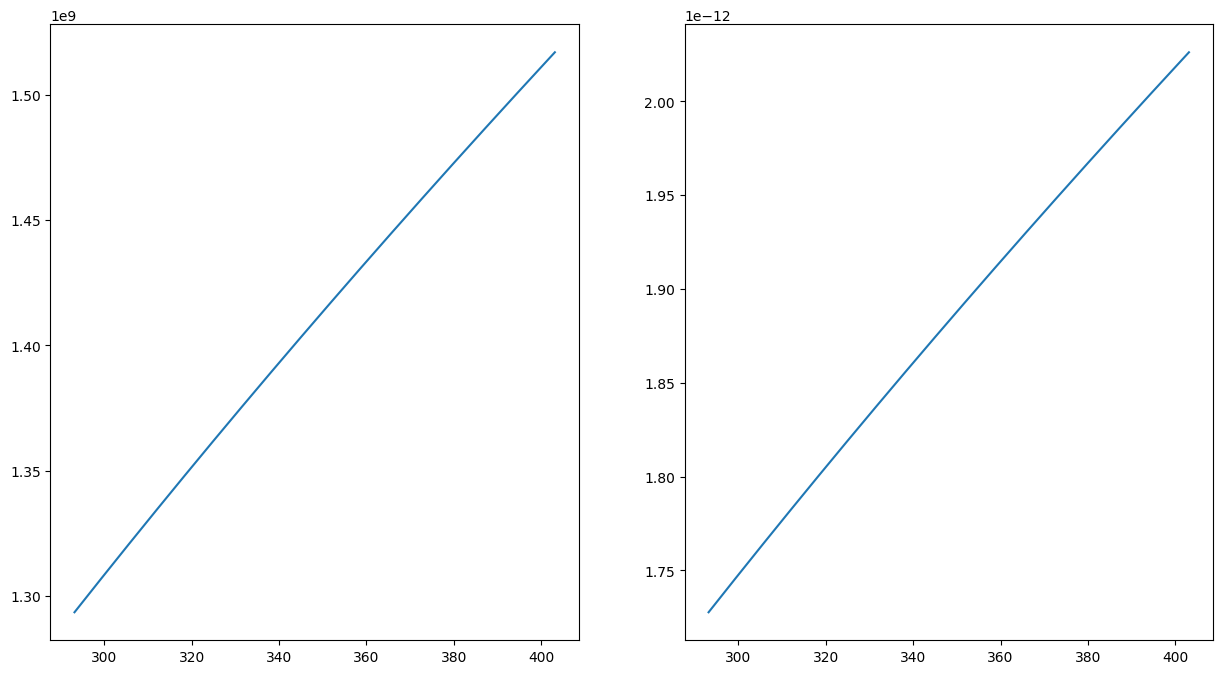

In [6]:
import matplotlib.pyplot as plt

T = np.linspace(20, 130, 1000) + 273.15
delta_nu = 2*f0*np.sqrt((2*k*T*np.log(2))/(M*c**2))
delta_lam = delta_nu*np.abs(-lam0/f0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
ax1.plot(T, delta_nu)
ax2.plot(T, delta_lam)

print(np.min(delta_nu))
print(np.max(delta_nu))
print(np.min(delta_lam))
print(np.max(delta_lam))

Clearly delta_nu and delta_lam monotonically increase over this range from delta_nu(T=20 degrees) = 1.29 GHz to delta_nu(T=130 degrees) = 1.51 GHz

delta_lam(T=20 degrees) = 1.73 pm to delta_nu(T=130 degrees) = 2.02 pm

In [7]:
delta_T = 130 - 20
alpha = 1e-6
delta_L = L * alpha * delta_T

lam_m = 2 * L / 1264223

print(f"Change from 20 to 130 degrees: {lam_m / L * delta_L} m")
print(f"Change per unit kelvin: {lam_m / L * delta_L / delta_T} m/degreesK")

Change from 20 to 130 degrees: 6.960797264406675e-11 m
Change per unit kelvin: 6.327997513096977e-13 m/degreesK


(e)

$$ \Delta \lambda_m \approx \frac{\lambda_0 ^ 2}{ 2L} $$

$$ \delta L = L \alpha \delta T $$

This implies that the mode separation is  
$$ \Delta \lambda_m ^{(new)} \approx \frac{\lambda_0 ^ 2}{ 2(L + \delta L)} = \frac{\lambda_0 ^ 2}{ 2(L + L \alpha \delta T)} $$

$$ \delta \Delta \lambda_m = \Delta \lambda_m ^{(new)} - \Delta \lambda_m = \frac{\lambda_0 ^ 2}{ 2(L + L \alpha \delta T)} - \frac{\lambda_0 ^ 2}{ 2L}$$

$$ \delta \Delta \lambda_m = \frac{\lambda_0 ^ 2}{ 2L}[\frac{1}{1+\alpha \delta T} - 1]$$
$$ \delta \Delta \lambda_m = \frac{\lambda_0 ^ 2}{ 2L}[\frac{1}{1+\alpha \delta T} - \frac{1+\alpha \delta T}{1+\alpha \delta T}]$$

$$ \delta \Delta \lambda_m = \frac{-\alpha \delta T}{1+\alpha \delta T} \frac{\lambda_0 ^ 2}{ 2L}$$
$$ \delta \Delta \lambda_m = \frac{-\alpha \delta T}{1+\alpha \delta T} \Delta \lambda_m $$

In [8]:
delta_lam_m_new = lam0**2 / (2*(L + delta_L))
delta_nu_m_new = c / (2*(L+delta_L))

print(f"Mode wavlength separation for  {delta_lam_m_new:e} m")
print(f"And separation in frequency is {delta_nu_m_new:e} Hz")

Mode wavlength separation for  5.004897e-13 m
And separation in frequency is 3.746994e+08 Hz


In [9]:
print(f"∆lambda_m (original) = {delta_lam_m:e} m")
print(f"∆lambda_m (new) = {delta_lam_m_new:e} m")
print(f"∆lambda_m (new) - ∆lambda_m (original) = {(delta_lam_m_new - delta_lam_m):e} m : this is from 20 degrees C to 130 degrees celsius")
print(f"∆lambda_m (new) - ∆lambda_m (original) = {((delta_lam_m_new - delta_lam_m)/delta_T):e} m per degree Kelvin")

∆lambda_m (original) = 5.005448e-13 m
∆lambda_m (new) = 5.004897e-13 m
∆lambda_m (new) - ∆lambda_m (original) = -5.505387e-17 m : this is from 20 degrees C to 130 degrees celsius
∆lambda_m (new) - ∆lambda_m (original) = -5.004897e-19 m per degree Kelvin


$$ \Delta \nu_m ^{(orginal)} = \frac{c}{2L} $$
$$ \Delta \nu_m ^{(new)} = \frac{c}{2(L + L \alpha \delta T)} $$
$$ \delta \Delta \nu_m = \Delta \nu_m ^{(new)} - \Delta \nu_m ^{(orginal)} = \frac{c}{2(L + L \alpha \delta T)} - \frac{c}{2L}$$
$$ \delta \Delta \nu_m = \frac{c}{2L}[\frac{1}{1 + \alpha \delta T} - 1]$$
$$ \delta \Delta \nu_m = \frac{c}{2L}[\frac{1}{1 + \alpha \delta T} - \frac{1 + \alpha \delta T}{1 +  \alpha \delta T}]$$
$$ \delta \Delta \nu_m = \frac{-\alpha \delta T}{1 + \alpha \delta T}\frac{c}{2L}$$
$$ \delta \Delta \nu_m = \frac{-\alpha \delta T}{1 + \alpha \delta T}\Delta \nu_m ^{(orginal)}$$

In [10]:
print(f"∆nu_m (original) = {delta_nu_m:e} Hz")
print(f"∆nu_m (new) = {delta_nu_m_new:e} Hz")
print(f"∆nu_m (new) - ∆nu_m (original) = {(delta_nu_m_new - delta_nu_m):e} Hz : this is from 20 degrees C to 130 degrees celsius")
print(f"∆nu_m (new) - ∆nu_m (original) = {((delta_nu_m_new - delta_nu_m)/delta_T):e} Hz per degree Kelvin")

∆nu_m (original) = 3.747406e+08 Hz
∆nu_m (new) = 3.746994e+08 Hz
∆nu_m (new) - ∆nu_m (original) = -4.121693e+04 Hz : this is from 20 degrees C to 130 degrees celsius
∆nu_m (new) - ∆nu_m (original) = -3.746994e+02 Hz per degree Kelvin


In [11]:
print(alpha * delta_T / (1 + alpha*delta_T) * delta_lam_m, "m") # Just double checking that my derivation was correct
print(alpha * delta_T / (1 + alpha*delta_T) * delta_nu_m, "Hz") # Just double checking that my derivation was correct

5.505387207407184e-17 m
41216.92911279759 Hz


(f)
One way that we can increase the output intensity is by adjusting the length of the cavity so that it is an integer multiple of lambda0/2, this would ensure that the light emitted at lambda0 is minimally attenuated by the spectral shape. 

Additionally, by reducing the linewidth of the laser, you will have a larger peak, so by reducing the temperature, you will decrease the linewidth, which (look at equation 4.6.8) will increase the gain coefficient.

# 4.12

![](eq4p2p7.png)

![](eq4p2p8.png)

In order to achieve more stimulated emission than spontaneous, R(stim) / R(spon) must be greater than 1  
$$ \frac{B_{21}\rho(\nu)}{A_{21}} > 1 $$

This begins when 
$$ \frac{B_{21}\rho(\nu)}{A_{21}} = 1 $$
$$ \rho(\nu) = \frac{A_{21}}{B_{21}} $$
$$ \rho(\nu) = \frac{8\pi h \nu^3}{c^3} = \frac{(N_{ph} h \nu)}{\Delta \nu}$$

$$ \rho(\nu) = \frac{8\pi h \nu^3}{c^3} = \frac{(N_{ph} h \nu)}{\Delta \nu}$$

$$ N_{ph} = \frac{\Delta \nu}{h \nu} \rho(\nu) $$

In [12]:
from scipy.constants import h, c

delta_nu = 5e9
lam = 488e-9
nu = c/lam

rho = 8*np.pi*h*nu**3 / c**3 

N_ph = delta_nu / (h*nu) *rho

print(f"{N_ph:e} photons per m^3")

1.760149e+15 photons per m^3


# 4.23

![](photon_cavity_lifetime.png)

$$ \tau_{ph} = n / (c \alpha_t) = n / (c(\alpha_s + \frac{1}{2L}ln(\frac{1}{R_1R_2})))$$

Thus, if $R_1 = R_2 = 1$, the logarithmic term goes to zero and $\tau_{ph} = n/(c\alpha_s)$

Text(0, 0.5, '$\\tau_{ph}$')

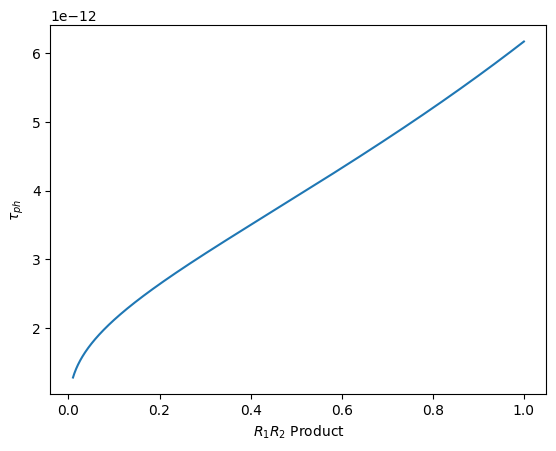

In [13]:
alpha_s = 20e2 # 20 per cm
L=300e-6
n=3.7

R1R2 = np.linspace(0.01, 1.0, 1000)

tau_ph = n / (c*(alpha_s+np.log(1/R1R2)/(2*L)))

plt.plot(R1R2, tau_ph)
plt.xlabel(r"$R_1 R_2$ Product")
plt.ylabel(r"$\tau_{ph}$")

Assuming the mirrors are perfect reflectors: 

In [14]:
print(f"tau_ph = {n / (c*alpha_s)} s")

tau_ph = 6.170935761165813e-12 s


If we assume a more reasonable reflectance, perhaps R1 = R2 = 0.8

In [15]:
print(f"tau_ph = {n / (c*(alpha_s+np.log(1/0.8)/(2*L)))} s")

tau_ph = 5.203356264770813e-12 s


# 4.24

![](fig4p32.png)

since we have assumed $n=p$, lets subsitute for n and p

$$n = n_i exp[(E_{Fn} - E_{Fi})/(K_BT)]$$
$$p = n_i exp[(E_{Fi} - E_{Fp})/(K_BT)]$$

Taking the product,  
$$np = n_i exp[(E_{Fn} - E_{Fi})/(K_BT)] \times n_i exp[(E_{Fi} - E_{Fp})/(K_BT)]$$

Using the fact taht $n=p$ we can simplify

$$n^2 = n_i^2 exp[(E_{Fn} - E_{Fp})/(K_BT)] $$
$$n = n_i exp[(E_{Fn} - E_{Fp})/(2K_BT)] $$

In [16]:
from scipy.constants import e
n_i = 2e6 # per cm^3
E_g = 1.42 # eV
T = 300

n = n_i*np.exp(E_g * e / (2*k*T))

print(f"n = {n:e} per cm^3")

n = 1.692408e+18 per cm^3


# 6.1 
Calculate the threshold small signal gain coefficient for ruby given the following data: threshold population inversion $5 \times 10^{22}$ $m^{-3}$, refractive index 1.5, linewidth $2 \times 10^{11}$ Hz, Einstein A coefficient 300 $s^{-1}$ and wavelength 694.3 nm.

![](pop_inv_wilson_and_hawkes.png)

For our case, let $g_2 = g_1$
$$ k = (N_2 - N_1) \frac{B_{21} h n }{\lambda_0 \Delta f}    $$
$$ k = (N_2 - N_1) \frac{B_{21} h n f}{c \Delta f}    $$



According to Planck's Law (Also, see page 298 in textbook)
$$ \frac{A_{21}}{B_{21}} = \frac{8\pi h \nu^3 n^3}{c^3} $$

$$ B_{21} = \frac{A_{21}c^3}{8\pi h \nu^3 n^3} $$

$$ k = (N_2 - N_1) \frac{A_{21}c^3 h n f}{8\pi h \nu^3 n^3 c \Delta f}    $$
$$ k = (N_2 - N_1) \frac{A_{21}c^2}{8\pi \nu^2 n^2 \Delta f}    $$

In [17]:
from scipy.constants import c
import numpy as np

population_inversion = 5e22 # per meter^3
n=1.5
A_21 = 300 # per second
delta_f = 2e11

f = c / (694.3e-9)

k = population_inversion*A_21*c**2 / (8*np.pi*(f**2)*(n**2)*delta_f)

print(f"small signal gain coefficient: k = {k}")

small signal gain coefficient: k = 0.6393419717771369


# 6.2 

Calculate the threshold pumping power for an Nd:glass laser, given that the critical population inversion is $9 \times 10^{21}$ $m^{-3}$, the spontaneous lifetime is 300 μs and that the upper laser level is at an energy of 1.4 eV. 

![](ex4p2p1.png)

The above equation is obviously for a 3 state laser, while Nd:glass lasers are technically 4 state lasers

In [18]:
from scipy.constants import h
N_0 = 9e21 # per meter^3
tau_sp = 300e-6
E = 1.4 * 1.6021766339999e-19
f = E / h

min_power_per_unit_volume = (N_0 / 2)*h*f/tau_sp
print(f"P_pmin/V = {min_power_per_unit_volume / (100**3)} W/cm^3")

P_pmin/V = 3.36457093139979 W/cm^3


# 6.3 
Estimate the efficiency of a GaAs laser operating well above threshold, given that n=3.6 and that the length of the laser cavity is 200 μm. Take the loss coefficient to be 800 m-1 and the internal quantum efficiency to be 0.8.

First, we calculate the reflectance of the semiconductor mirrors, assuming perfect cleaving

In [19]:
n1 = 3.6
n2 = 1.0

R = (n2 - n1)**2 / (n2 + n1)**2

print(f"R = {R}")

R = 0.31947069943289236


Recall from class that 
$$ P_{out} = A[J-J_{th}]\eta_i \frac{h \nu}{q}[\frac{ln(1/R)}{\gamma L + ln(1/R)}] $$

We know know that the bandgap of GaAs is 1.42 eV, therefore, $\frac{h \nu}{q} = 1.42 V$

$$ P_{out} = A[J-J_{th}]\eta_i (1.42 volts)[\frac{ln(1/R)}{\gamma L + ln(1/R)}] $$
Assuming that $ J >>J_{th}$, we can simplify  
$$ P_{out} = A J \eta_i (1.42 volts)[\frac{ln(1/R)}{\gamma L + ln(1/R)}] $$

![](efficiency_def.png)

The Input electrical power will simply be $ A J V$, therefore the efficiency is

$$ Efficiency = \frac{A J \eta_i (1.42 volts)[\frac{ln(1/R)}{\gamma L + ln(1/R)}]}{ A J V} $$
$$ Efficiency = \frac{\eta_i (1.42 volts)[\frac{ln(1/R)}{\gamma L + ln(1/R)}]}{V} $$
$$ Efficiency \times V = \eta_i (1.42 volts)[\frac{ln(1/R)}{\gamma L + ln(1/R)}] $$

In [20]:
eta_i = 0.8
gamma = 800
L = 200e-6

Efficiency_times_V = eta_i * 1.42 * np.log(1/R)/(gamma*L + np.log(1/R))

print(f"The efficiency per unit voltage is: Efficiency = {Efficiency_times_V}/V")

The efficiency per unit voltage is: Efficiency = 0.9963017166040297/V
